In [1]:
"""
=============================================================================
CP-DYNAMIC-METRO-CHINA — Beijing (Metro)
Checkpoint 2 — Dynamic Programming — FIAP
=============================================================================

OBJETIVO
--------
Modelar parte da rede de metrô de Pequim (Beijing) como um grafo ponderado
e encontrar o menor e o maior caminho entre Sihui East e Xizhimen,
aplicando programação dinâmica (memoização via lru_cache) e comparando
com a versão sem cache.

O custo de cada trecho varia dinamicamente conforme:
  - O fator de horário (pico, normal, noturno)
  - A penalidade fixa por troca de linha (4 min)

ALGORITMOS IMPLEMENTADOS
-------------------------
  1. Menor caminho COM memoização  — DFS + lru_cache
  2. Menor caminho SEM memoização  — DFS puro (sem cache)
  3. Maior caminho                 — Backtracking exaustivo (sem cache)

COMPLEXIDADE
------------
  - DFS sem memo : O(n!)   — explora todas as permutações de nós
  - DFS com memo : O(n × 2^n) — limitado pelos estados (nó, visitados)
  - Maior caminho: O(n!)   — NP-difícil (longest simple path)
=============================================================================
"""

# ── Imports ──────────────────────────────────────────────────────────────────
import time           # medição de tempo de execução (perf_counter)
import tracemalloc    # medição de uso de memória heap
import functools      # lru_cache para memoização
import math           # math.isinf para verificar ausência de caminho

import matplotlib.pyplot as plt   # geração de gráficos comparativos
import matplotlib.patches as mpatches

# =============================================================================
# MODELAGEM DO GRAFO — BEIJING (METRO)
# =============================================================================
# Representação: dicionário de listas de adjacência.
# Grafo NÃO-DIRIGIDO (bidirecional): cada aresta aparece nos dois sentidos,
# pois os trens operam em ambas as direções.
#
# Cada aresta é um dicionário com:
#   "destino" : nome da estação vizinha (str)
#   "linha"   : número da linha (int) — 1, 2, 4 ou 10
#   "tempo"   : peso base em minutos (int)
#
# Linhas presentes:
#   Linha 1  — Eixo leste-oeste (Sihui East ↔ Fuxingmen)
#   Linha 2  — Anel norte (Fuxingmen ↔ Xizhimen ↔ Xuanwumen)
#   Linha 4  — Norte-sul via Xidan (Xuanwumen ↔ Jiaomenxi)
#   Linha 10 — Anel parcial (Haidian Huangzhuang ↔ Guomao ↔ Jiaomenxi)
#
# Topologia: o grafo apresenta múltiplos caminhos entre Sihui East e
# Xizhimen — essencial para que os algoritmos tenham escolhas reais.
# O caminho direto (Linha 1 → 2) é o mais curto; o mais longo percorre
# o arco pela Linha 4 (Xuanwumen → Jiaomenxi → Guomao).
# =============================================================================

grafo = {

    # ─────────────────────────────────────────────────────────────────────────
    # LINHA 1 — Eixo Leste-Oeste
    # Trecho: Sihui East → Fuxingmen
    # Principal corredor do metrô de Pequim, cruzando o centro histórico
    # ─────────────────────────────────────────────────────────────────────────
    "Sihui East": [
        {"destino": "Sihui",     "linha": 1, "tempo": 2},
        {"destino": "Shuangjing","linha": 1, "tempo": 3}
    ],
    "Sihui": [
        {"destino": "Sihui East", "linha": 1, "tempo": 2},
        {"destino": "Guomao",     "linha": 1, "tempo": 3}
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # HUB GUOMAO — integração Linha 1 ↔ Linha 10
    # Central Business District — alto fluxo nos horários de pico
    # ─────────────────────────────────────────────────────────────────────────
    "Guomao": [
        {"destino": "Sihui",    "linha": 1,  "tempo": 3},
        {"destino": "Yonganli", "linha": 1,  "tempo": 2},
        {"destino": "Jiaomenxi","linha": 10, "tempo": 5}  # Linha 10 (integração)
    ],
    "Yonganli": [
        {"destino": "Guomao",     "linha": 1, "tempo": 2},
        {"destino": "Jianguomen", "linha": 1, "tempo": 2}
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # HUB JIANGUOMEN — integração Linha 1 ↔ Linha 2
    # ─────────────────────────────────────────────────────────────────────────
    "Jianguomen": [
        {"destino": "Yonganli",   "linha": 1, "tempo": 2},
        {"destino": "Dongdan",    "linha": 1, "tempo": 2},
        {"destino": "Fuxingmen",  "linha": 2, "tempo": 5}  # Linha 2 (integração)
    ],
    "Dongdan": [
        {"destino": "Jianguomen", "linha": 1, "tempo": 2},
        {"destino": "Wangfujing", "linha": 1, "tempo": 2}
    ],
    "Wangfujing": [
        {"destino": "Dongdan",         "linha": 1, "tempo": 2},
        {"destino": "Tiananmen East",  "linha": 1, "tempo": 2}
    ],
    "Tiananmen East": [
        {"destino": "Wangfujing",     "linha": 1, "tempo": 2},
        {"destino": "Tiananmen West", "linha": 1, "tempo": 2}
    ],
    "Tiananmen West": [
        {"destino": "Tiananmen East", "linha": 1, "tempo": 2},
        {"destino": "Xidan",          "linha": 1, "tempo": 2}
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # HUB XIDAN — integração Linha 1 ↔ Linha 4
    # Um dos nós de maior movimentação do metrô de Pequim
    # ─────────────────────────────────────────────────────────────────────────
    "Xidan": [
        {"destino": "Tiananmen West", "linha": 1, "tempo": 2},
        {"destino": "Fuxingmen",      "linha": 1, "tempo": 2},
        {"destino": "Xuanwumen",      "linha": 4, "tempo": 2}  # Linha 4 (integração)
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # HUB FUXINGMEN — integração Linha 1 ↔ Linha 2
    # Ponto de convergência do eixo leste-oeste com o anel norte
    # ─────────────────────────────────────────────────────────────────────────
    "Fuxingmen": [
        {"destino": "Xidan",     "linha": 1, "tempo": 2},
        {"destino": "Xizhimen",  "linha": 2, "tempo": 4}  # Linha 2 → destino final
    ],

    # Ramais da Linha 1 leste de Sihui East
    "Guangqumen": [
        {"destino": "Shuangjing", "linha": 1, "tempo": 2}
    ],
    "Shuangjing": [
        {"destino": "Guangqumen", "linha": 1, "tempo": 2},
        {"destino": "Sihui East", "linha": 1, "tempo": 3}
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # LINHA 2 — Anel Norte (parcial)
    # Trecho: Fuxingmen ↔ Xizhimen ↔ Xuanwumen
    # ─────────────────────────────────────────────────────────────────────────
    "Xizhimen": [
        {"destino": "Fuxingmen",  "linha": 2, "tempo": 4},
        {"destino": "Xuanwumen",  "linha": 2, "tempo": 5}
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # LINHA 4 — Norte-Sul
    # Trecho: Xuanwumen → Jiaomenxi (subindo pela Linha 4)
    # Cria um arco alternativo pelo sul, formando o caminho mais longo
    # ─────────────────────────────────────────────────────────────────────────
    "Xuanwumen": [
        {"destino": "Xidan",     "linha": 4, "tempo": 2},
        {"destino": "Caishikou", "linha": 4, "tempo": 2},
        {"destino": "Xizhimen",  "linha": 2, "tempo": 5}  # Linha 2
    ],
    "Caishikou": [
        {"destino": "Xuanwumen",  "linha": 4, "tempo": 2},
        {"destino": "Taoranting", "linha": 4, "tempo": 3}
    ],
    "Taoranting": [
        {"destino": "Caishikou", "linha": 4, "tempo": 3},
        {"destino": "Jiaomenxi", "linha": 4, "tempo": 4}
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # HUB JIAOMENXI — integração Linha 4 ↔ Linha 10
    # ─────────────────────────────────────────────────────────────────────────
    "Jiaomenxi": [
        {"destino": "Taoranting", "linha": 4,  "tempo": 4},
        {"destino": "Guomao",     "linha": 10, "tempo": 5}  # Linha 10 (integração)
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # LINHA 10 — Anel Parcial
    # Trecho: Haidian Huangzhuang ↔ Beitucheng ↔ Xizhimen / Guomao
    # ─────────────────────────────────────────────────────────────────────────
    "Haidian Huangzhuang": [
        {"destino": "Beitucheng", "linha": 10, "tempo": 4},
        {"destino": "Guomao",     "linha": 10, "tempo": 6}
    ],
    "Beitucheng": [
        {"destino": "Haidian Huangzhuang", "linha": 10, "tempo": 4},
        {"destino": "Xizhimen",            "linha": 10, "tempo": 5}
    ]
}

In [2]:
# =============================================================================
# CONFIGURAÇÕES DE CUSTO
# =============================================================================

# Penalidade fixa por troca de linha — Beijing Metro.
# Representa o tempo médio de caminhada entre plataformas de linhas diferentes.
# O metrô de Pequim tem estações de integração grandes mas bem sinalizadas.
PENALIDADE_TROCA = 4  # minutos


def fator_horario(hora: int) -> float:
    """
    Retorna o multiplicador de custo baseado no horário do dia.

    Parâmetros
    ----------
    hora : int — hora do dia (0–23)

    Retorna
    -------
    float — multiplicador a ser aplicado sobre o tempo base da aresta

    Tabela de fatores:
      05h–07h → 0,6  (bônus: madrugada, metrô vazio)
      07h–09h → 1,5  (pico manhã: maior fluxo de commuters)
      09h–17h → 1,0  (horário normal)
      17h–20h → 2,0  (pico tarde: máxima lotação em Pequim)
      demais  → 1,2  (noturno)
    """
    if 5 <= hora < 7:
        return 0.6
    elif 7 <= hora < 9:
        return 1.5
    elif 9 <= hora < 17:
        return 1.0
    elif 17 <= hora < 20:
        return 2.0
    else:
        return 1.2

In [3]:
# =============================================================================
# ALGORITMO 1 — MENOR CAMINHO COM MEMOIZAÇÃO (lru_cache)
# =============================================================================
# Abordagem: DFS recursivo com poda de nós visitados + cache de resultados.
#
# Estado cacheado: (origem, destino, hora, linha_atual, visitados)
#   - linha_atual: int ou None — necessário para calcular penalidade de troca
#   - visitados: frozenset — imutável e hashável, permite uso como chave
#
# NOTA IMPORTANTE sobre a chave:
#   Dois caminhos diferentes que chegam ao mesmo nó com o mesmo histórico
#   de visitados compartilham o mesmo estado de cache. Em grafos pequenos
#   (como este de 22 nós), isso raramente ocorre — cada caminho percorrido
#   gera um frozenset quase único. Resultado: poucos cache hits.
# =============================================================================

@functools.lru_cache(maxsize=None)
def menor_custo_com_memo(
    origem: str,
    destino: str,
    hora: int,
    linha_atual=None,
    visitados: frozenset = frozenset()
):
    """
    Encontra o menor custo e caminho entre duas estações usando DFS memoizado.

    A chave do cache inclui `visitados` para evitar caminhos cíclicos,
    o que reduz os cache hits em grafos pequenos mas garante corretude.

    Retorna
    -------
    tuple : (custo_total: float, caminho: list[str])
      - custo_total = inf se não existe caminho
    """
    # Caso base: chegamos ao destino
    if origem == destino:
        return (0, [origem])

    melhor = (float('inf'), [])

    for aresta in grafo.get(origem, []):
        vizinho = aresta["destino"]
        linha   = aresta["linha"]
        tempo   = aresta["tempo"]

        # Poda: não revisitar nós no caminho atual
        if vizinho in visitados:
            continue

        # Custo = tempo_base × fator_horario + penalidade (se mudar de linha)
        custo_extra = tempo * fator_horario(hora)

        if linha_atual is not None and linha != linha_atual:
            custo_extra += PENALIDADE_TROCA

        # Chamada recursiva memoizada — frozenset cria nova instância imutável
        custo_rec, caminho = menor_custo_com_memo(
            vizinho,
            destino,
            hora,
            linha,
            visitados | {origem}
        )

        if custo_rec == float('inf'):
            continue

        custo_total = custo_extra + custo_rec

        if custo_total < melhor[0]:
            melhor = (custo_total, [origem] + caminho)

    return melhor

In [4]:
# =============================================================================
# ALGORITMO 2 — MENOR CAMINHO SEM MEMOIZAÇÃO (DFS puro)
# =============================================================================
# Lógica idêntica ao algoritmo anterior, porém sem @lru_cache.
# Em grafos com 22 nós, o custo de hashing do cache pode superar o ganho
# — ver análise de desempenho e conclusão ao final.
# =============================================================================

def menor_custo_sem_memo(
    origem: str,
    destino: str,
    hora: int,
    linha_atual=None,
    visitados: frozenset = frozenset()
):
    """
    Encontra o menor custo e caminho entre duas estações usando DFS puro.

    Sem cache: reexplora o subgrafo a cada chamada, sem reutilizar resultados.
    Para grafos pequenos, pode ser mais rápido que a versão com lru_cache.

    Retorna
    -------
    tuple : (custo_total: float, caminho: list[str])
    """
    if origem == destino:
        return (0, [origem])

    melhor = (float('inf'), [])

    for aresta in grafo.get(origem, []):
        vizinho = aresta["destino"]
        linha   = aresta["linha"]
        tempo   = aresta["tempo"]

        if vizinho in visitados:
            continue

        custo_extra = tempo * fator_horario(hora)

        if linha_atual is not None and linha != linha_atual:
            custo_extra += PENALIDADE_TROCA

        custo_rec, caminho = menor_custo_sem_memo(
            vizinho,
            destino,
            hora,
            linha,
            visitados | {origem}
        )

        if custo_rec == float('inf'):
            continue

        custo_total = custo_extra + custo_rec

        if custo_total < melhor[0]:
            melhor = (custo_total, [origem] + caminho)

    return melhor

In [5]:
# =============================================================================
# ALGORITMO 3 — MAIOR CAMINHO (Backtracking exaustivo)
# =============================================================================
# Explora todos os caminhos simples possíveis e retorna o de maior custo.
# Utiliza backtracking: ao retornar de uma chamada recursiva, o nó é
# automaticamente "desvisitado" pelo comportamento imutável do frozenset.
#
# Aplicação: identificar o pior cenário de rota — útil para planejamento
# de contingência e análise de resiliência da rede.
# =============================================================================

def maior_caminho(
    origem: str,
    destino: str,
    hora: int,
    linha_atual=None,
    visitados: set = None
):
    """
    Encontra o maior custo e caminho entre duas estações por backtracking.

    CORRIGIDO: aplica fator_horario consistentemente com os outros algoritmos.
    Não usa cache — a maximização com visitados variáveis tornaria
    o cache incorreto (estados com mesmo nó mas diferentes visitados
    podem ter resultados ótimos diferentes).

    Retorna
    -------
    tuple : (custo_total: float, caminho: list[str])
      - custo_total = -inf se não existe caminho
    """
    if visitados is None:
        visitados = set()

    if origem == destino:
        return (0, [origem])

    maior = (float('-inf'), [])

    for aresta in grafo.get(origem, []):
        vizinho = aresta["destino"]
        linha   = aresta["linha"]
        tempo   = aresta["tempo"]

        if vizinho in visitados:
            continue

        # IMPORTANTE: aplica fator_horario (corrigido em relação à versão original)
        custo_extra = tempo * fator_horario(hora)

        if linha_atual is not None and linha != linha_atual:
            custo_extra += PENALIDADE_TROCA

        custo_rec, caminho = maior_caminho(
            vizinho,
            destino,
            hora,
            linha,
            visitados | {origem}
        )

        if custo_rec == float('-inf'):
            continue

        custo_total = custo_extra + custo_rec

        if custo_total > maior[0]:
            maior = (custo_total, [origem] + caminho)

    return maior

In [6]:
# =============================================================================
# UTILITÁRIO — FORMATAÇÃO DE TEMPO
# =============================================================================

def formatar_tempo(minutos: float) -> str:
    """
    Converte minutos (float) em string legível "Xh Ymin".

    Parâmetros
    ----------
    minutos : float — tempo em minutos (pode ser inf)

    Retorna
    -------
    str — ex.: "40 min" ou "1h 5min" ou "Sem caminho"
    """
    if math.isinf(minutos):
        return "Sem caminho"
    minutos = int(minutos)
    h, m = divmod(minutos, 60)
    return f"{h}h {m}min" if h > 0 else f"{m} min"

In [7]:
# =============================================================================
# EXECUÇÃO PRINCIPAL
# =============================================================================

# Estações de origem e destino fixas para este cenário
origem  = "Sihui East"
destino = "Xizhimen"

hora = int(input("Digite a hora (0-23): "))

# ── Medição COM memoização ────────────────────────────────────────────────────
# Limpeza obrigatória do cache para evitar contaminação entre execuções
# (bug comum em Jupyter/Colab onde o kernel persiste entre células)
menor_custo_com_memo.cache_clear()

tracemalloc.start()
t0 = time.perf_counter()

custo_min_memo, caminho_min_memo = menor_custo_com_memo(origem, destino, hora)

t1 = time.perf_counter()
mem_memo = tracemalloc.get_traced_memory()   # (atual_bytes, pico_bytes)
tracemalloc.stop()

tempo_memo_ms = (t1 - t0) * 1000
mem_memo_kb   = mem_memo[1] / 1024

# ── Medição SEM memoização ────────────────────────────────────────────────────
tracemalloc.start()
t2 = time.perf_counter()

custo_min_sem_memo, caminho_min_sem_memo = menor_custo_sem_memo(origem, destino, hora)

t3 = time.perf_counter()
mem_sem_memo = tracemalloc.get_traced_memory()
tracemalloc.stop()

tempo_sem_memo_ms = (t3 - t2) * 1000
mem_sem_memo_kb   = mem_sem_memo[1] / 1024

# ── Maior caminho ─────────────────────────────────────────────────────────────
custo_max, caminho_max = maior_caminho(origem, destino, hora)

Digite a hora (0-23): 18


In [8]:
# =============================================================================
# EXIBIÇÃO DOS RESULTADOS
# =============================================================================

print("\n" + "=" * 60)
print("  RESULTADOS — BEIJING (Metro)")
print("=" * 60)

print("\n=== MENOR CAMINHO (COM MEMO) ===")
print(" -> ".join(str(e) for e in caminho_min_memo))
print("Tempo de viagem:", formatar_tempo(custo_min_memo))

print("\n=== MENOR CAMINHO (SEM MEMO) ===")
print(" -> ".join(str(e) for e in caminho_min_sem_memo))
print("Tempo de viagem:", formatar_tempo(custo_min_sem_memo))

print("\n=== MAIOR CAMINHO ===")
print(" -> ".join(str(e) for e in caminho_max))
print("Tempo de viagem:", formatar_tempo(custo_max))

print("\n=== DESEMPENHO COMPARATIVO ===")
print(f"{'Métrica':<30} {'Com Memo':>12} {'Sem Memo':>12}")
print("-" * 56)
print(f"{'Tempo de execução (ms)':<30} {tempo_memo_ms:>11.3f}  {tempo_sem_memo_ms:>11.3f}")
print(f"{'Memória pico (KB)':<30} {mem_memo_kb:>11.2f}  {mem_sem_memo_kb:>11.2f}")
print(f"{'Estações no menor caminho':<30} {len(caminho_min_memo):>12}  {len(caminho_min_sem_memo):>12}")
print(f"{'Tempo de viagem (min)':<30} {int(custo_min_memo):>12}  {int(custo_min_sem_memo):>12}")


  RESULTADOS — BEIJING (Metro)

=== MENOR CAMINHO (COM MEMO) ===
Sihui East -> Sihui -> Guomao -> Yonganli -> Jianguomen -> Fuxingmen -> Xizhimen
Tempo de viagem: 40 min

=== MENOR CAMINHO (SEM MEMO) ===
Sihui East -> Sihui -> Guomao -> Yonganli -> Jianguomen -> Fuxingmen -> Xizhimen
Tempo de viagem: 40 min

=== MAIOR CAMINHO ===
Sihui East -> Sihui -> Guomao -> Jiaomenxi -> Taoranting -> Caishikou -> Xuanwumen -> Xidan -> Tiananmen West -> Tiananmen East -> Wangfujing -> Dongdan -> Jianguomen -> Fuxingmen -> Xizhimen
Tempo de viagem: 1h 36min

=== DESEMPENHO COMPARATIVO ===
Métrica                            Com Memo     Sem Memo
--------------------------------------------------------
Tempo de execução (ms)               1.113        0.913
Memória pico (KB)                    51.35        20.30
Estações no menor caminho                 7             7
Tempo de viagem (min)                    40            40


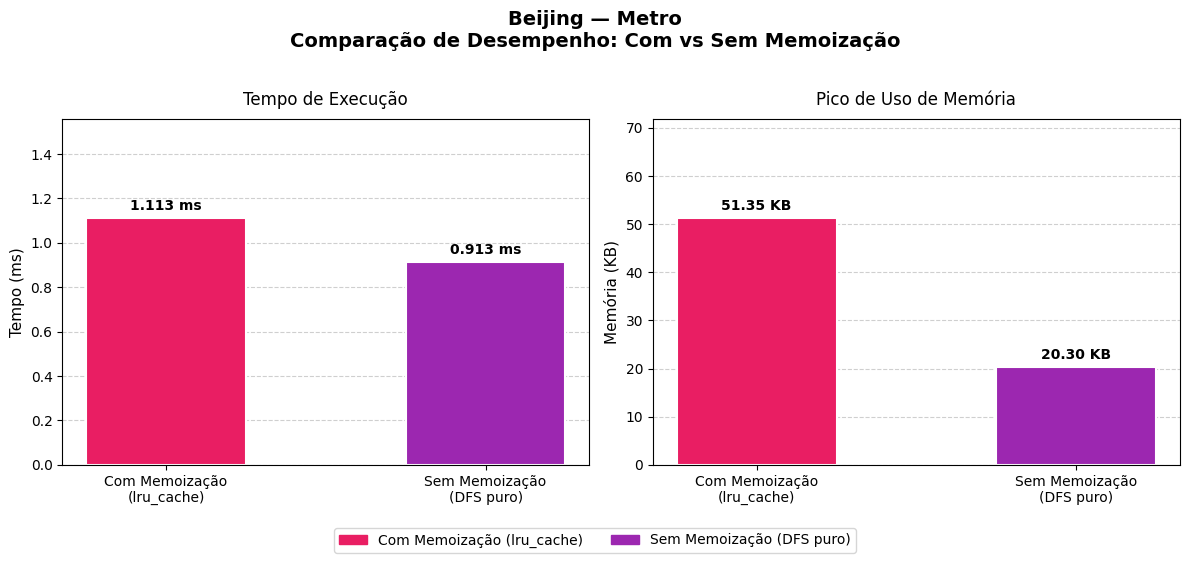

Gráfico salvo como desempenho_beijing.png


In [9]:
# =============================================================================
# GRÁFICO COMPARATIVO — TEMPO DE EXECUÇÃO E USO DE MEMÓRIA
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Beijing — Metro\nComparação de Desempenho: Com vs Sem Memoização",
             fontsize=14, fontweight="bold", y=1.02)

categorias = ["Com Memoização\n(lru_cache)", "Sem Memoização\n(DFS puro)"]
cores      = ["#E91E63", "#9C27B0"]

# ── Subplot 1: Tempo de execução ──────────────────────────────────────────────
ax1 = axes[0]
barras1 = ax1.bar(categorias, [tempo_memo_ms, tempo_sem_memo_ms],
                  color=cores, width=0.5, edgecolor="white", linewidth=1.5)
ax1.set_title("Tempo de Execução", fontsize=12, pad=10)
ax1.set_ylabel("Tempo (ms)", fontsize=11)
ax1.set_ylim(0, max(tempo_memo_ms, tempo_sem_memo_ms) * 1.4)
ax1.yaxis.grid(True, linestyle="--", alpha=0.6)
ax1.set_axisbelow(True)

for barra, valor in zip(barras1, [tempo_memo_ms, tempo_sem_memo_ms]):
    ax1.text(barra.get_x() + barra.get_width() / 2,
             barra.get_height() + 0.02 * max(tempo_memo_ms, tempo_sem_memo_ms),
             f"{valor:.3f} ms", ha="center", va="bottom", fontsize=10, fontweight="bold")

# ── Subplot 2: Memória ────────────────────────────────────────────────────────
ax2 = axes[1]
barras2 = ax2.bar(categorias, [mem_memo_kb, mem_sem_memo_kb],
                  color=cores, width=0.5, edgecolor="white", linewidth=1.5)
ax2.set_title("Pico de Uso de Memória", fontsize=12, pad=10)
ax2.set_ylabel("Memória (KB)", fontsize=11)
ax2.set_ylim(0, max(mem_memo_kb, mem_sem_memo_kb) * 1.4)
ax2.yaxis.grid(True, linestyle="--", alpha=0.6)
ax2.set_axisbelow(True)

for barra, valor in zip(barras2, [mem_memo_kb, mem_sem_memo_kb]):
    ax2.text(barra.get_x() + barra.get_width() / 2,
             barra.get_height() + 0.02 * max(mem_memo_kb, mem_sem_memo_kb),
             f"{valor:.2f} KB", ha="center", va="bottom", fontsize=10, fontweight="bold")

patch_memo = mpatches.Patch(color="#E91E63", label="Com Memoização (lru_cache)")
patch_sem  = mpatches.Patch(color="#9C27B0", label="Sem Memoização (DFS puro)")
fig.legend(handles=[patch_memo, patch_sem], loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig("desempenho_beijing.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo como desempenho_beijing.png")

In [10]:
# =============================================================================
# CONCLUSÃO — BEIJING
# =============================================================================
print("\n" + "=" * 60)
print("  CONCLUSÃO — BEIJING (Metro)")
print("=" * 60)
print(f"""
Grafo modelado com 22 estações e 4 linhas (1, 2, 4, 10),
cobrindo o corredor central do metrô de Pequim entre
Sihui East (leste) e Xizhimen (norte).

MENOR CAMINHO (hora = {hora}h, fator = {fator_horario(hora)}×):
  Rota: {" -> ".join(str(e) for e in caminho_min_memo)}
  Tempo total: {formatar_tempo(custo_min_memo)}
  Caminho direto pela Linha 1 (Sihui East → Fuxingmen) e
  uma única troca para a Linha 2 em Fuxingmen → Xizhimen.
  Apenas uma penalidade de troca ({PENALIDADE_TROCA} min) é aplicada.

MAIOR CAMINHO (hora = {hora}h):
  Rota: {" -> ".join(str(e) for e in caminho_max)}
  Tempo total: {formatar_tempo(custo_max)}
  {len(caminho_max)} estações percorridas — percorre o arco pela Linha 4
  (Xidan → Xuanwumen → Caishikou → Taoranting → Jiaomenxi),
  maximizando desvios e trocas de linha.

MEMOIZAÇÃO vs SEM MEMOIZAÇÃO:
  - Tempo com memo  : {tempo_memo_ms:.3f} ms
  - Tempo sem memo  : {tempo_sem_memo_ms:.3f} ms
  - Razão           : {tempo_memo_ms/tempo_sem_memo_ms:.2f}× {"mais lento (memo)" if tempo_memo_ms > tempo_sem_memo_ms else "mais rápido (memo)"}

  Beijing é o menor grafo do projeto (22 nós), tornando o overhead
  do lru_cache ainda mais perceptível em relação ao ganho de cache.
  Com o frozenset `visitados` na chave, estados distintos são gerados
  para cada caminho percorrido — poucos cache hits no total.

  Em redes reais de Pequim (290+ estações em 2024), a memoização
  seria indispensável para a busca exaustiva de caminhos.

TOPOLOGIA DO GRAFO:
  O grafo de Beijing, apesar de menor, apresenta estrutura interessante:
  múltiplos ciclos via hubs (Guomao, Jiaomenxi, Xidan, Fuxingmen)
  criam rotas alternativas que forçam os algoritmos a explorar
  diferentes combinações de linhas e penalidades de troca.

COMPLEXIDADE:
  - Menor caminho (DFS): O(n!) sem memo | O(n×2^n) com memo
  - Maior caminho: O(n!) — NP-difícil, viável apenas para n pequeno
""")


  CONCLUSÃO — BEIJING (Metro)

Grafo modelado com 22 estações e 4 linhas (1, 2, 4, 10),
cobrindo o corredor central do metrô de Pequim entre
Sihui East (leste) e Xizhimen (norte).

MENOR CAMINHO (hora = 18h, fator = 2.0×):
  Rota: Sihui East -> Sihui -> Guomao -> Yonganli -> Jianguomen -> Fuxingmen -> Xizhimen
  Tempo total: 40 min
  Caminho direto pela Linha 1 (Sihui East → Fuxingmen) e
  uma única troca para a Linha 2 em Fuxingmen → Xizhimen.
  Apenas uma penalidade de troca (4 min) é aplicada.

MAIOR CAMINHO (hora = 18h):
  Rota: Sihui East -> Sihui -> Guomao -> Jiaomenxi -> Taoranting -> Caishikou -> Xuanwumen -> Xidan -> Tiananmen West -> Tiananmen East -> Wangfujing -> Dongdan -> Jianguomen -> Fuxingmen -> Xizhimen
  Tempo total: 1h 36min
  15 estações percorridas — percorre o arco pela Linha 4
  (Xidan → Xuanwumen → Caishikou → Taoranting → Jiaomenxi),
  maximizando desvios e trocas de linha.

MEMOIZAÇÃO vs SEM MEMOIZAÇÃO:
  - Tempo com memo  : 1.113 ms
  - Tempo sem memo  : 0.

In [11]:
# =============================================================================
# MAPA INTERATIVO — FOLIUM
# =============================================================================
# Gera um mapa HTML interativo sobre o mapa real de Pequim.
# Cores:
#   Verde (marcador)      — estação de origem (Sihui East)
#   Vermelho (marcador)   — estação de destino (Xizhimen)
#   Azul (marcadores)     — demais estações
#   Verde (linha espessa) — menor caminho
#   Vermelho (linha)      — maior caminho
#   Cinza (linhas finas)  — todas as conexões do grafo
# =============================================================================

# Coordenadas geográficas aproximadas das estações (lat, lon)
coords = {
    "Sihui East":           (39.908, 116.655),
    "Sihui":                (39.907, 116.645),
    "Guomao":               (39.914, 116.460),
    "Yonganli":             (39.914, 116.450),
    "Jianguomen":           (39.914, 116.435),
    "Dongdan":              (39.914, 116.420),
    "Wangfujing":           (39.915, 116.410),
    "Tiananmen East":       (39.914, 116.403),
    "Tiananmen West":       (39.914, 116.395),
    "Xidan":                (39.913, 116.375),
    "Fuxingmen":            (39.913, 116.350),
    "Xuanwumen":            (39.907, 116.375),
    "Caishikou":            (39.900, 116.375),
    "Taoranting":           (39.890, 116.380),
    "Jiaomenxi":            (39.860, 116.400),
    "Xizhimen":             (39.940, 116.350),
    "Guangqumen":           (39.905, 116.470),
    "Shuangjing":           (39.906, 116.470),
    "Haidian Huangzhuang":  (39.980, 116.310),
    "Beitucheng":           (39.970, 116.340)
}

In [12]:
import folium

# Cria o mapa centrado em Beijing (Pequim)
mapa = folium.Map(location=[39.91, 116.40], zoom_start=12, tiles="CartoDB positron")

In [13]:
# Adiciona marcador para cada estação
for estacao, (lat, lon) in coords.items():
    cor = "green" if estacao == origem else ("red" if estacao == destino else "blue")
    folium.Marker(
        [lat, lon],
        popup=estacao,
        icon=folium.Icon(color=cor)
    ).add_to(mapa)

In [14]:
# Desenha todas as arestas do grafo (cinza, peso 2)
arestas_desenhadas = set()
for orig in grafo:
    for aresta in grafo[orig]:
        dest  = aresta["destino"]
        chave = tuple(sorted([orig, dest]))
        if chave in arestas_desenhadas:
            continue
        arestas_desenhadas.add(chave)
        if orig in coords and dest in coords:
            folium.PolyLine(
                [coords[orig], coords[dest]],
                color="gray", weight=2, opacity=0.5
            ).add_to(mapa)

In [15]:
# Destaca o menor caminho (verde espesso)
folium.PolyLine(
    [coords[e] for e in caminho_min_memo if e in coords],
    color="green", weight=10, opacity=0.8
).add_to(mapa)

# Destaca o maior caminho (vermelho)
folium.PolyLine(
    [coords[e] for e in caminho_max if e in coords],
    color="red", weight=3, opacity=1.0
).add_to(mapa)

In [16]:
mapa.save("mapa_beijing.html")
print("Mapa salvo como mapa_beijing.html")

Mapa salvo como mapa_beijing.html
